# Chain Stationary SCBA

Este notebook implementa una primera versión del estado estacionario para la **cadena de una banda** en el nivel **SCBA estacionario en $(k,\omega)$**.

La idea es reemplazar la evolución completa en dos tiempos por una solución autoconsistente en frecuencia, imponiendo invariancia temporal de traslación. En esa aproximación:

$$
G^R(k,\omega)=\frac{1}{\omega-\epsilon_k-\Sigma^R(k,\omega)}.
$$

$$
G^<(k,\omega)=|G^R(k,\omega)|^2\,\Sigma^<(k,\omega),
\qquad
G^>(k,\omega)=|G^R(k,\omega)|^2\,\Sigma^>(k,\omega).
$$

y las self-energies menores y mayores se obtienen por convolución con el kernel bosónico:

$$
\Sigma^{<,>}(k,\omega)
=
\frac{i}{L}\sum_q \int\frac{d\Omega}{2\pi}\,
\Xi_q^{<,>}(\Omega)\,
G^{<,>}(k-q,\omega-\Omega).
$$



$$
F(\omega)=\frac{-iG^<(\omega)}{A(\omega)}.
$$



In [134]:
ROOT = "/home/jalil/jalil_codes/Projects_2026/KBE-DrivenElectrons"
cd(ROOT)

import Pkg
Pkg.activate(ROOT)
# Pkg.instantiate()   # úsalo solo la primera vez si faltan paquetes

using JLD2
using PyPlot

include(joinpath(ROOT, "main.jl"))

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=15, titlesize=14)
rc("xtick", labelsize=11)
rc("ytick", labelsize=11)
rc("legend", fontsize=10)


  Activating project at `~/jalil_codes/Projects_2026/KBE-DrivenElectrons`


## Parámetros

Aquí fijamos un caso de trabajo. La idea es mantener una grilla moderada para poder iterar rápido y luego subir resolución si la convergencia es razonable.


In [148]:
params = (
    L = 80,
    u = 0.0,
    γ = 1.0,
    α = 0.5,
    Tb = 0.2,
    η = 0.05,
    λ_q = 0.5,
    s_q = 1.0,
    ωb0 = 0.1,
    v_b = 0.2,
    ωmax = 6.0,
    Nω = 601,   # impar para centrar la malla en ω=0
    Tinit = 0.2,
    μ = 0.0,
    maxiter = 120,
    mix = 0.5,
    tol = 1e-13,
    δ_reg = 0.05,
)


(L = 80, u = 0.0, γ = 1.0, α = 0.5, Tb = 0.2, η = 0.05, λ_q = 0.5, s_q = 1.0, ωb0 = 0.1, v_b = 0.2, ωmax = 6.0, Nω = 601, Tinit = 0.2, μ = 0.0, maxiter = 120, mix = 0.5, tol = 1.0e-13, δ_reg = 0.05)

In [149]:
    # L = 80,
    # u = 0.0,
    # γ = 1.0,
    # α = 0.5,
    # Tb = 0.5,
    # η = 0.5,
    # λ_q = 0.5,
    # s_q = 1.0,
    # ωb0 = 0.1,
    # v_b = 0.2,
    # ωmax = 6.0,
    # Nω = 401,   # impar para centrar la malla en ω=0
    # Tinit = 0.5,
    # μ = 0.0,
    # maxiter = 100,
    # mix = 0.5,
    # tol = 1e-13,

## Funciones auxiliares

Estas son las piezas básicas del solver:

- construcción de `\Xi_q^{<,>}(\omega)`
- convolución discreta en frecuencia
- reconstrucción aproximada de `\Re\Sigma^R` a partir de la parte espectral

Aquí usamos la identidad

$$
A_\Sigma(k,\omega)=i\left[\Sigma^>(k,\omega)-\Sigma^<(k,\omega)\right]
$$

y una versión discreta de Kramers-Kronig para obtener `\Re\Sigma^R`.


In [150]:
fermi_fd(ω, T, μ) = 1 / (exp((ω - μ) / T) + 1)

function build_bath_kernels(ωs, model)
    L = model.L
    Nω = length(ωs)
    ΞLω = zeros(ComplexF64, L, Nω)
    ΞGω = zeros(ComplexF64, L, Nω)
    for q in 1:L
        for (iω, ω) in enumerate(ωs)
            Aω = boson_spectral_A(ω, model.ωq[q], model.η)
            ΞLω[q, iω] = (-1im) * bose(ω; model) * Aω * model.g2q[q]
            ΞGω[q, iω] = (-1im) * (bose(ω; model) + 1) * Aω * model.g2q[q]
        end
    end
    return ΞLω, ΞGω
end

function update_sigma_lesser_greater!(ΣL, ΣG, GL, GG, ΞLω, ΞGω, kmq_idx, dω)
    L, Nω = size(GL)
    mid = Nω ÷ 2 + 1
    fill!(ΣL, 0)
    fill!(ΣG, 0)

    @inbounds for k in 1:L
        for q in 1:L
            kq = kmq_idx[k, q]
            for iω in 1:Nω
                accL = zero(ComplexF64)
                accG = zero(ComplexF64)
                for jω in 1:Nω
                    lω = iω - jω + mid
                    if 1 <= lω <= Nω
                        accL += ΞLω[q, jω] * GL[kq, lω]
                        accG += ΞGω[q, jω] * GG[kq, lω]
                    end
                end
                ΣL[k, iω] += 1im * accL * dω / (2π * L)
                ΣG[k, iω] += 1im * accG * dω / (2π * L)
            end
        end
    end
    return ΣL, ΣG
end

function kk_real_part(Aspec, ωs, dω)
    Nω = length(ωs)
    ReΣ = zeros(Float64, Nω)
    @inbounds for i in 1:Nω
        acc = 0.0
        ωi = ωs[i]
        for j in 1:Nω
            j == i && continue
            acc += Aspec[j] / (ωi - ωs[j])
        end
        ReΣ[i] = acc * dω / (2π)
    end
    return ReΣ
end


kk_real_part (generic function with 1 method)

## Solver estacionario

La iteración usa como semilla un estado térmico electrónico bare a temperatura `Tinit`. A cada paso:

1. se actualizan `\Sigma^{<,>}`
2. se reconstruye `\Sigma^R`
3. se actualizan `G^R`, `G^<` y `G^>`
4. se mezcla con el paso anterior para estabilizar

La parte imaginaria retarded la cerramos con

$$
\mathrm{Im}\,\Sigma^R(k,\omega)
=
-\frac{1}{2}A_\Sigma(k,\omega),
$$

de modo que

$$
\Sigma^R(k,\omega)
=
\Re\Sigma^R(k,\omega)
+
i\,\mathrm{Im}\Sigma^R(k,\omega).
$$


## Qué hace exactamente la iteración

El punto central del solver es que `G` y `\Sigma` se determinan mutuamente:

- si conoces `G^{<,>}`, puedes construir `\Sigma^{<,>}` por convolución con el baño
- si conoces `\Sigma^R`, `\Sigma^<` y `\Sigma^>`, puedes reconstruir `G^R`, `G^<` y `G^>`

Entonces resolvemos el problema por **iteración autoconsistente**.

### 1. Semilla inicial

Empezamos con un Green function bare, es decir:

$$
G_0^R(k,\omega)=\frac{1}{\omega-\epsilon_k+i\eta},
$$

y construimos una ocupación inicial tipo Fermi-Dirac a temperatura `Tinit`:

$$
G_0^<(k,\omega)=i f(\omega;T_{\mathrm{init}}) A_0(k,\omega),
$$

$$
G_0^>(k,\omega)=-i [1-f(\omega;T_{\mathrm{init}})] A_0(k,\omega).
$$

Esta no es todavía la solución autoconsistente; es solo un punto de partida.

### 2. Actualización de las self-energies

Con `G^{<,>}` fijos en una iteración dada, calculamos

$$
\Sigma^{<,>}(k,\omega)
=
\frac{i}{L}\sum_q \int\frac{d\Omega}{2\pi}
\Xi_q^{<,>}(\Omega) G^{<,>}(k-q,\omega-\Omega).
$$

En el código, esto se hace como una convolución discreta sobre la malla de `\omega`.

### 3. Reconstrucción de la parte retarded

De `\Sigma^>` y `\Sigma^<` formamos primero la parte espectral

$$
A_\Sigma(k,\omega)=i[\Sigma^>(k,\omega)-\Sigma^<(k,\omega)].
$$

Luego usamos:

$$
\mathrm{Im}\Sigma^R(k,\omega)=-\frac{1}{2}A_\Sigma(k,\omega),
$$

y una Kramers-Kronig discreta para estimar `\Re\Sigma^R`.

### 4. Actualización de los Green functions

Con la nueva `\Sigma^R` se actualiza:

$$
G^R(k,\omega)=\frac{1}{\omega-\epsilon_k-\Sigma^R(k,\omega)},
$$

y luego

$$
G^<(k,\omega)=|G^R(k,\omega)|^2\Sigma^<(k,\omega),
$$

$$
G^>(k,\omega)=|G^R(k,\omega)|^2\Sigma^>(k,\omega).
$$

### 5. Mezcla numérica (`mix`)

No usamos el update nuevo de forma brutal. En vez de eso, mezclamos la solución vieja y la nueva:

$$
G_{\mathrm{used}}=(1-\text{mix}) G_{\mathrm{old}} + \text{mix}\, G_{\mathrm{new}}.
$$

Esto se hace para `G^R`, `G^<` y `G^>`.

La razón es puramente numérica:

- `mix=1` usa la actualización completa y puede oscilar o divergir
- `mix` pequeño estabiliza la iteración, aunque la vuelve más lenta

Así que `mix` **no es un parámetro físico**, solo un parámetro de convergencia del algoritmo.

### 5b. Regulador imaginario pequeño (`δ_reg`)

Además dejamos un ancho imaginario pequeño en el denominador de `G^R`:

$$
G^R(k,\omega)=\frac{1}{\omega-\epsilon_k-\Sigma^R(k,\omega)+i\delta_{\mathrm{reg}}}.
$$

Esto se usa como regularización numérica para:

- suavizar picos demasiado agudos,
- evitar denominadores casi singulares,
- estabilizar la iteración autoconsistente.

No es un parámetro físico nuevo; es un regulador auxiliar que conviene mantener pequeño.

### 6. Criterio de parada

Después de cada iteración medimos cuánto cambió la solución:

$$
\text{err}
=
\max\left(
\max |G^<_{\mathrm{new}}-G^<_{\mathrm{old}}|,
\max |G^>_{\mathrm{new}}-G^>_{\mathrm{old}}|
\right).
$$

Cuando ese error baja por debajo de `tol`, consideramos que la iteración ya es autoconsistente.

### Resumen

La lógica completa es:

1. partir de una semilla bare
2. construir `\Sigma^{<,>}`
3. reconstruir `\Sigma^R`
4. actualizar `G`
5. mezclar con el paso anterior
6. repetir hasta converger

Eso es exactamente lo que implementa la función `stationary_scba_chain`.


In [151]:
function stationary_scba_chain(; L=60, u=0.0, γ=1.0, α=2.5, Tb=0.1, η=0.05, λ_q=0.5, s_q=1.0,
                               ωb0=0.1, v_b=0.2, ωmax=4.0, Nω=301, Tinit=1.0, μ=0.0,
                               maxiter=20, mix=0.5, tol=1e-5, δ_reg=0.01)
    isodd(Nω) || throw(ArgumentError("Nω must be odd so the ω-grid is centered at zero"))

    model = ModelElectronBath(; L=L, u=u, γ=γ, α=α, Tb=Tb, η=η, λ_q=λ_q, s_q=s_q,
                              ωb0=ωb0, v_b=v_b, bath_type=:dispersion,
                              boson_kernel=:spectral, wq_profile=:power_exp)

    ks = model.ks
    ϵs = ϵ_k(ks; u, γ)
    ωs = collect(range(-ωmax, ωmax, length=Nω))
    dω = ωs[2] - ωs[1]

    ΞLω, ΞGω = build_bath_kernels(ωs, model)

    GR = zeros(ComplexF64, L, Nω)
    GL = zeros(ComplexF64, L, Nω)
    GG = zeros(ComplexF64, L, Nω)
    ΣL = zeros(ComplexF64, L, Nω)
    ΣG = zeros(ComplexF64, L, Nω)
    ΣR = zeros(ComplexF64, L, Nω)

    for k in 1:L, iω in 1:Nω
        GR[k, iω] = inv(complex(ωs[iω], δ_reg) - ϵs[k])
        Akw = -2 * imag(GR[k, iω])
        fω = fermi_fd(ωs[iω], Tinit, μ)
        GL[k, iω] = 1im * fω * Akw
        GG[k, iω] = -1im * (1 - fω) * Akw
    end

    errors = Float64[]
    for iter in 1:maxiter
        oldGL = copy(GL)
        oldGG = copy(GG)

        update_sigma_lesser_greater!(ΣL, ΣG, GL, GG, ΞLω, ΞGω, model.kmq_idx, dω)

        for k in 1:L
            AΣ = 1im .* (ΣG[k, :] .- ΣL[k, :])
            ReΣ = kk_real_part(real.(AΣ), ωs, dω)
            ImΣ = -0.5 .* real.(AΣ)
            ΣR[k, :] .= ReΣ .+ 1im .* ImΣ
        end

        for k in 1:L, iω in 1:Nω
            GR_new = inv(complex(ωs[iω], δ_reg) - ϵs[k] - ΣR[k, iω])
            GL_new = abs2(GR_new) * ΣL[k, iω]
            GG_new = abs2(GR_new) * ΣG[k, iω]
            GR[k, iω] = (1 - mix) * GR[k, iω] + mix * GR_new
            GL[k, iω] = (1 - mix) * GL[k, iω] + mix * GL_new
            GG[k, iω] = (1 - mix) * GG[k, iω] + mix * GG_new
        end

        err = max(maximum(abs.(GL .- oldGL)), maximum(abs.(GG .- oldGG)))
        push!(errors, err)
        println("iter=$(iter) err=$(err)")
        err < tol && break
    end

    Akw = real.(1im .* (GG .- GL))
    A_sum = vec(sum(Akw; dims=1)) ./ L
    minus_iGless_sum = vec(real.((-1im) .* sum(GL; dims=1))) ./ L
    F_num = fill(NaN, Nω)
    mask = abs.(A_sum) .> 1e-10
    F_num[mask] .= minus_iGless_sum[mask] ./ A_sum[mask]
    nk = vec(sum(real.((-1im) .* GL); dims=2)) .* dω ./ (2π)

    return (; model, ks, ϵs, ωs, GR, GL, GG, ΣR, ΣL, ΣG, Akw, A_sum, minus_iGless_sum, F_num, nk, errors)
end


stationary_scba_chain (generic function with 1 method)

## Ejecutar el solver

Empezamos con parámetros modestos para comprobar que la iteración baja el error y produce una distribución razonable.


In [152]:
out = stationary_scba_chain(; params...)


iter=1 err=17.049588019295403
iter=2 err=8.123959476663442
iter=3 err=4.669755888232988
iter=4 err=2.8850789852490655
iter=5 err=1.9160646872003806
iter=6 err=1.3727521866791523
iter=7 err=1.0306314329759552
iter=8 err=0.8128432169398607
iter=9 err=0.6523833391368008
iter=10 err=0.5363046554888777
iter=11 err=0.44841328929847446
iter=12 err=0.3772157760717092
iter=13 err=0.3199966903873448
iter=14 err=0.2707394474217706
iter=15 err=0.22841124433239868
iter=16 err=0.19215695508799113
iter=17 err=0.16122390237130135
iter=18 err=0.13493399070935252
iter=19 err=0.11267406962148518
iter=20 err=0.09389240212482752
iter=21 err=0.07882562381371327
iter=22 err=0.06615325875659961
iter=23 err=0.05540546529882695
iter=24 err=0.046319102305369064
iter=25 err=0.038659244268389514
iter=26 err=0.03221837681160444
iter=27 err=0.026814830856715766
iter=28 err=0.02229076771897409
iter=29 err=0.01850994318232324
iter=30 err=0.015355411878117842
iter=31 err=0.012727281654381084
iter=32 err=0.0105405885322

(model = ModelElectronBath{var"#ModelElectronBath##30#ModelElectronBath##31"{Float64, Float64, Float64, Float64, Float64, Float64, Vector{Float64}}}(80, 0.1, 0.2, 0.0, 1.0, 0.5, 1.0, 10.0, 50.0, 3.141592653589793, 2.0, 0.1, false, 3.0, 20.0, :dispersion, :linear, :spectral, 0.05, 20.0, 0.01, 0.1, 0.2, 0.07853981633974483, [-3.141592653589793, -3.0630528372500483, -2.9845130209103035, -2.9059732045705586, -2.827433388230814, -2.748893571891069, -2.670353755551324, -2.5918139392115793, -2.5132741228718345, -2.4347343065320897  …  2.356194490192345, 2.4347343065320897, 2.5132741228718345, 2.5918139392115793, 2.670353755551324, 2.748893571891069, 2.827433388230814, 2.9059732045705586, 2.9845130209103035, 3.0630528372500483], :power_exp, 1.0, 0.5, [0.005866744366933474, 0.006692996507785236, 0.007630595035986259, 0.008693513859493025, 0.009897259223614898, 0.011258986709927964, 0.012797613704776285, 0.014533922411414296, 0.016490646935213408, 0.01869253604378496  …  0.021166380807779522, 0.

In [153]:
out.errors


120-element Vector{Float64}:
 17.049588019295403
  8.123959476663442
  4.669755888232988
  2.8850789852490655
  1.9160646872003806
  1.3727521866791523
  1.0306314329759552
  0.8128432169398607
  0.6523833391368008
  0.5363046554888777
  0.44841328929847446
  0.3772157760717092
  0.3199966903873448
  ⋮
  3.1185676263589812e-9
  2.562890788482264e-9
  2.1062249722092474e-9
  1.7309291777678482e-9
  1.4225038924564615e-9
  1.1690359791316496e-9
  9.607310502701694e-10
  7.895430975679574e-10
  6.488583004227166e-10
  5.332405628166725e-10
  4.3822501183399254e-10
  3.6013991788763633e-10

## Visualización del estado estacionario candidato

La salida se organiza en tres paneles:

- `n_k`
- `A_{sum k}(ω)` e `iG^<_{sum k}(ω)`
- `F(ω)` comparada con la Fermi del baño


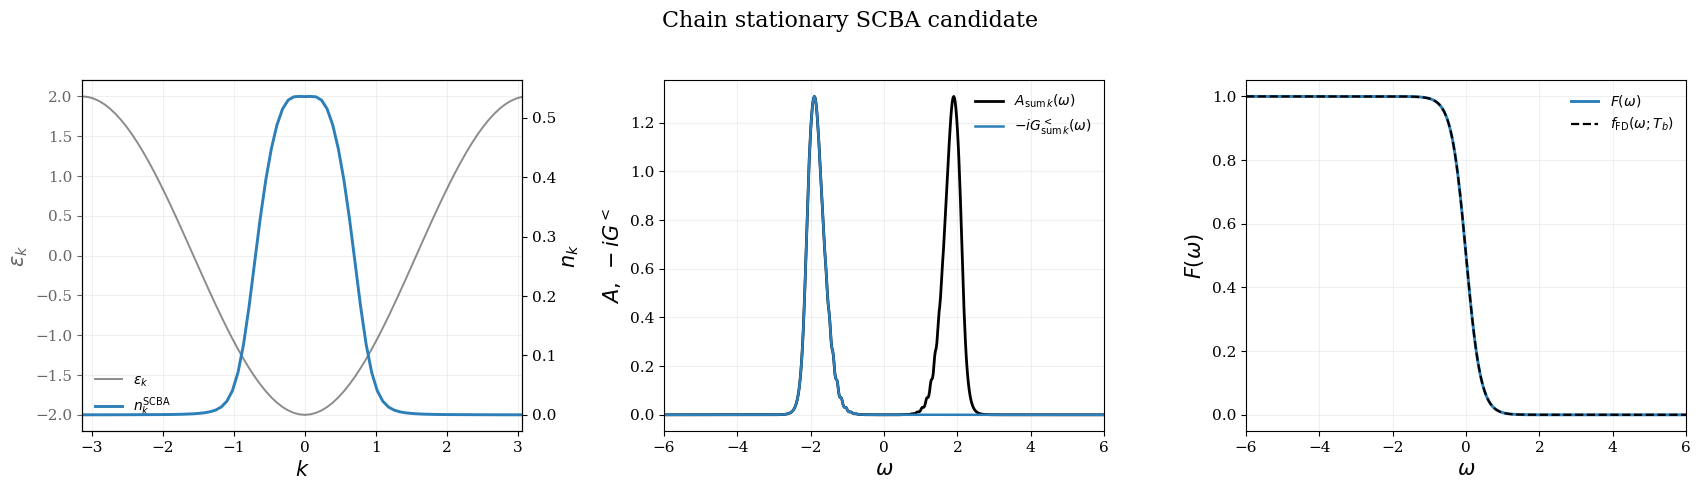

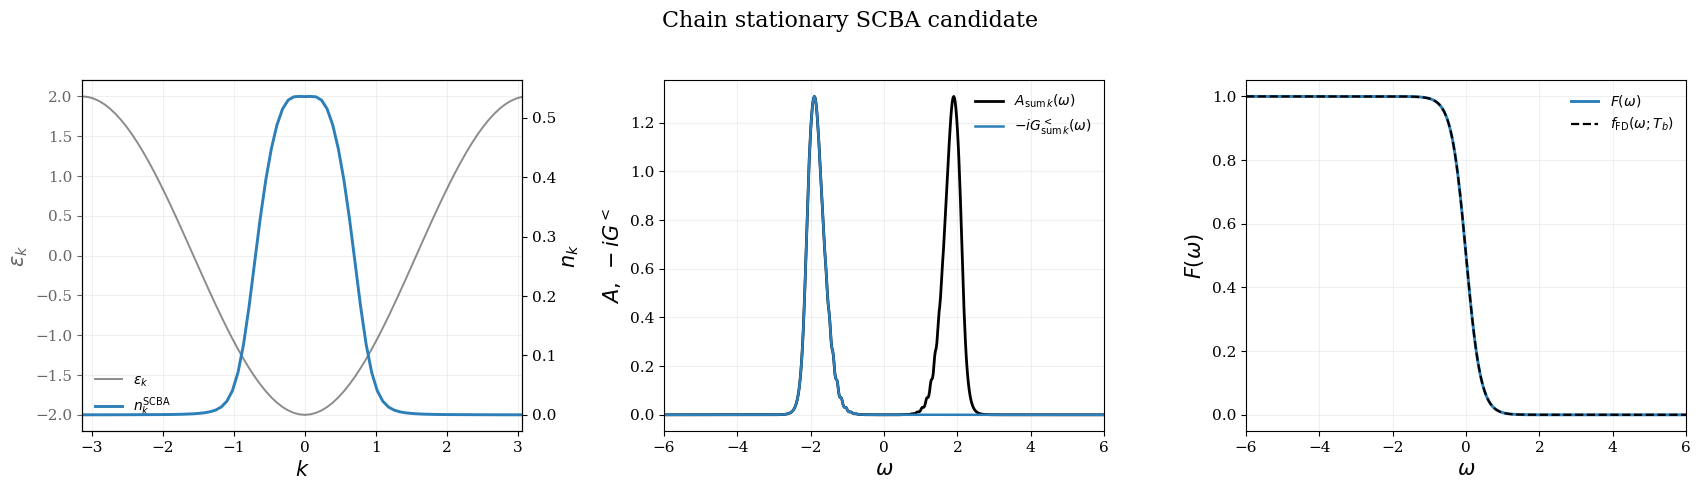

In [154]:
F_fd_bath = fermi_fd.(out.ωs, params.Tb, params.μ)

fig, axs = subplots(1, 3; figsize=(17.2, 4.8))

axs[1].plot(out.ks, out.ϵs; color="black", linewidth=1.4, alpha=0.45, label=raw"$\epsilon_k$")
axs1_twin = axs[1].twinx()
axs1_twin.plot(out.ks, out.nk; color="#2c7fb8", linewidth=2.1, label=raw"$n_k^{\mathrm{SCBA}}$")
axs[1].set_xlabel(raw"$k$")
axs[1].set_ylabel(raw"$\epsilon_k$", color="#666666")
axs1_twin.set_ylabel(raw"$n_k$")
axs[1].tick_params(axis="y", colors="#666666")
axs[1].set_xlim(first(out.ks), last(out.ks))
axs[1].grid(alpha=0.18)
lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = axs1_twin.get_legend_handles_labels()
axs[1].legend(vcat(lines1, lines2), vcat(labels1, labels2); frameon=false, loc="best")

axs[2].plot(out.ωs, out.A_sum; color="black", linewidth=2.0, label=raw"$A_{\mathrm{sum}\,k}(\omega)$")
axs[2].plot(out.ωs, out.minus_iGless_sum; color="#2c7fb8", linewidth=1.8, label=raw"$-iG^{<}_{\mathrm{sum}\,k}(\omega)$")
axs[2].set_xlabel(raw"$\omega$")
axs[2].set_ylabel(raw"$A,\; -iG^<$")
axs[2].set_xlim(first(out.ωs), last(out.ωs))
axs[2].grid(alpha=0.18)
axs[2].legend(frameon=false, loc="best")

axs[3].plot(out.ωs, out.F_num; color="#2c7fb8", linewidth=2.1, label=raw"$F(\omega)$")
axs[3].plot(out.ωs, F_fd_bath; color="black", linestyle="--", linewidth=1.6, label=raw"$f_{\mathrm{FD}}(\omega;T_b)$")
axs[3].set_xlabel(raw"$\omega$")
axs[3].set_ylabel(raw"$F(\omega)$")
axs[3].set_xlim(first(out.ωs), last(out.ωs))
axs[3].set_ylim(-0.05, 1.05)
axs[3].grid(alpha=0.18)
axs[3].legend(frameon=false, loc="best")

fig.suptitle("Chain stationary SCBA candidate", fontsize=16, y=1.02)
fig.tight_layout()
fig


## Guardar la salida

Si quieres exportar resultados para compararlos luego con las corridas temporales, esta celda guarda la figura y las cantidades principales.


In [ ]:
tag = "L$(params.L)_α$(params.α)_Tb$(params.Tb)_η$(params.η)_pc$(params.λ_q)_Nω$(params.Nω)"
png_out = joinpath("distributions", "chain_stationary_scba_notebook_" * tag * ".png")
jld2_out = joinpath("distributions", "chain_stationary_scba_notebook_" * tag * ".jld2")

fig.savefig(png_out; dpi=220, bbox_inches="tight")
out_save = (; ks=out.ks, ϵs=out.ϵs, ωs=out.ωs, GR=out.GR, GL=out.GL, GG=out.GG,
             ΣR=out.ΣR, ΣL=out.ΣL, ΣG=out.ΣG, Akw=out.Akw, A_sum=out.A_sum,
             minus_iGless_sum=out.minus_iGless_sum, F_num=out.F_num, nk=out.nk, errors=out.errors)
@save jld2_out out_save

println("Saved " * png_out)
println("Saved " * jld2_out)


## Comentarios

Esta implementación es una primera base y todavía admite mejoras importantes:

- tratamiento más fino de la reconstrucción de `\Sigma^R`
- mejor control del soporte en frecuencia
- mezcla adaptativa
- comparación sistemática con las corridas temporales a `t=60`

Además, si al abrir el notebook no reconoce paquetes, la causa típica es que Julia no quedó en el entorno del repo. La primera celda ya hace:

```julia
Pkg.activate(ROOT)
```

y, si hiciera falta instalar dependencias en otra máquina, basta con descomentar:

$$
\texttt{Pkg.instantiate()}
$$

Pero ya sirve como punto de partida claro para estudiar el estado estacionario de la cadena sin integrar toda la KBE en dos tiempos.
